# 06 Hallazgos ciudadanos

Cada hallazgo se construye **solo** con salidas validadas de 03–05 y recibe un estado de publicación por reglas:

| Estado | Regla |
|---|---|
| `PUBLICABLE` | Dato descriptivo de un universo validado. |
| `PUBLICABLE_CON_CAUTELA` | Patrón o comparación `ROBUSTO`, o dato que depende de un clasificador sin validación manual. |
| `SOLO_DIRECCION` | Comparación con dirección estable pero magnitud sensible a la ventana: se publica el rango, no una cifra. |
| `SOLO_INVESTIGACION` | Anomalía que exige expedientes antes de publicar. |
| `NO_PUBLICABLE` | Comparación `NO_ROBUSTA` o afirmación que SECOP II no sostiene. |

Las tablas públicas no contienen nombres de personas.

In [15]:
import re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

RAIZ = Path.cwd().resolve()
# Busca la raíz del proyecto (carpeta que contiene funciones/secop_utils.py)
for _p in [RAIZ, *RAIZ.parents][:6]:
    if (_p / "funciones" / "secop_utils.py").exists():
        RAIZ = _p
        break
else:
    raise FileNotFoundError("No se encontró funciones/secop_utils.py; abra el notebook dentro del proyecto")
sys.path.insert(0, str(RAIZ / "funciones"))
import secop_utils as su

VERSION_NB = "06.v2.0"
ETAPA = "06_hallazgos"
SALIDA = su.carpeta_etapa(RAIZ, ETAPA)
GRAF = SALIDA / "graficos"
GRAF.mkdir(exist_ok=True)
man03, r03 = su.abrir_etapa(RAIZ, "03_cps")
man04, r04 = su.abrir_etapa(RAIZ, "04_comparabilidad")
man05, r05 = su.abrir_etapa(RAIZ, "05_patrones")
L = {k: su.leer_csv(v) for k, v in {**r04, **r05}.items() if str(v).endswith(".csv")}
b = su.leer_csv(r03["base_cps"])
ventanas = L["ventanas"]
VALIDACION = man03["conteos"]["validacion_subtipo"]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})


MESES_ES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]


def mes_es(fecha):
    return f"{MESES_ES[fecha.month - 1]}-{fecha.year}"


def etiqueta_ventana(v, admin):
    # Rótulo tomado de las fechas reales de la ventana (corrige el error de rótulos de la v1).
    f = ventanas.loc[ventanas["ventana"].eq(v) & ventanas["administracion"].eq(admin)].iloc[0]
    return f"{mes_es(f['inicio'])} a {mes_es(f['fin_excl'] - pd.Timedelta(days=1))}"


def res(v, admin, col):
    r = L["resumen_ventanas"]
    return float(r.loc[r["ventana"].eq(v) & r["administracion"].eq(admin), col].iloc[0])


def dictamen(metrica):
    return L["robustez"].set_index("metrica").loc[metrica, "dictamen"]


def rango_cambio(metrica):
    fila = L["robustez"].set_index("metrica").loc[metrica, ["anio3_ene_ago", "meses_16_32", "meses_17_32"]]
    return float(fila.min()), float(fila.max()), float(fila["anio3_ene_ago"])


def estado_por_dictamen(d, usa_subtipo=False):
    base = {"ROBUSTO": "PUBLICABLE_CON_CAUTELA", "ESTABLE": "PUBLICABLE_CON_CAUTELA",
            "DIRECCION_ROBUSTA_MAGNITUD_SENSIBLE": "SOLO_DIRECCION"}.get(d, "NO_PUBLICABLE")
    return base


def guardar_fig(fig, nombre):
    ruta = GRAF / nombre
    fig.tight_layout()
    fig.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(ruta)))
    return su.rel(ruta, RAIZ)


P_A, P_J = etiqueta_ventana("anio3_ene_ago", su.ADMINS[0]), etiqueta_ventana("anio3_ene_ago", su.ADMINS[1])
PERIODO_PRINCIPAL = f"Alfonso: {P_A} | Jonathan: {P_J}"
hallazgos = []


def es(texto):
    # Formato numérico colombiano: 3,526.5 -> 3.526,5
    return re.sub(r"\d{1,3}(?:,\d{3})+(?:\.\d+)?|\d+\.\d+",
                  lambda m: m.group(0).translate(str.maketrans(",.", ".,")), texto)


def hallazgo(qid, pregunta, respuesta, universo, periodo, evidencia, clasificacion, estado, limitacion, grafico=""):
    respuesta = es(respuesta)
    hallazgos.append(dict(id=qid, pregunta=pregunta, respuesta=respuesta, universo=universo, periodo=periodo,
                          evidencia=evidencia, grafico=grafico, clasificacion=clasificacion,
                          estado_publicacion=estado, limitacion=limitacion))
    display(Markdown(f"**{qid} · {pregunta}**  \n{respuesta}  \n*Estado:* `{estado}` — *Límite:* {limitacion}"))

print("Ventana principal:", PERIODO_PRINCIPAL, "| validación de subtipo:", VALIDACION)

Ventana principal: Alfonso: ene-2022 a ago-2022 | Jonathan: ene-2026 a ago-2026 | validación de subtipo: SIN_VALIDACION_MANUAL


## Q01 · ¿Cuánto dura un CPS de la Alcaldía central?

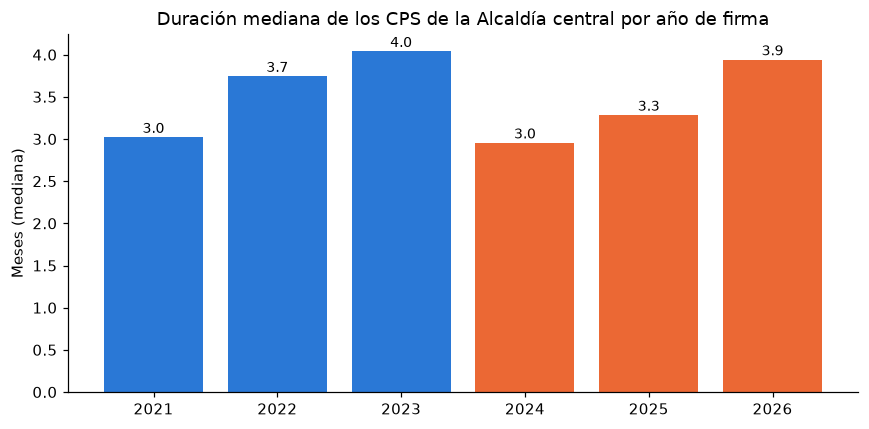

**Q01 · ¿Cuánto dura un CPS?**  
Entre abril de 2021 y el corte, la duración mediana por año de firma osciló entre 3,0 y 4,0 meses; el 92,6 % de los contratos duró menos de seis meses.  
*Estado:* `PUBLICABLE` — *Límite:* Vigencia pactada registrada (ya incluye prórrogas); no son días trabajados.

duracion_dias_incl,<1 mes,1–3 meses,3–6 meses,6–9 meses,9–12 meses
anio,,,,,
2021,3.2,34.2,61.3,1.3,0.0
2022,1.0,25.3,73.1,0.5,0.1
2023,7.2,16.2,54.0,19.5,3.1
2024,1.7,49.5,37.9,10.4,0.6
2025,2.7,28.9,63.0,4.3,1.0
2026,0.2,34.6,62.5,2.3,0.3


In [16]:
c = b.loc[b["es_central"] & b["apto_intervalo"] & b["fecha_firma"].ge("2021-04-01")].copy()
c["anio"] = c["fecha_firma"].dt.year
bandas = pd.cut(c["duracion_dias_incl"], [0, 30, 91, 182, 274, 367], right=False,
                labels=["<1 mes", "1–3 meses", "3–6 meses", "6–9 meses", "9–12 meses"])
dist = pd.crosstab(c["anio"], bandas, normalize="index").mul(100).round(1)
dur_anio = c.groupby("anio")["duracion_dias_incl"].median()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dur_anio.index.astype(str), dur_anio.values / 30.4375, color=[su.COLORES["Alfonso Eljach"] if a < 2024 else su.COLORES["Jonathan Vásquez"] for a in dur_anio.index])
ax.set_ylabel("Meses (mediana)")
ax.set_title("Duración mediana de los CPS de la Alcaldía central por año de firma")
for x, y in zip(range(len(dur_anio)), dur_anio.values / 30.4375):
    ax.text(x, y + 0.05, f"{y:.1f}", ha="center", fontsize=9)
g1 = guardar_fig(fig, "g01_duracion_por_anio.png")
pct_menos6 = float((c["duracion_dias_incl"] < 182).mean() * 100)
hallazgo("Q01", "¿Cuánto dura un CPS?",
         f"Entre abril de 2021 y el corte, la duración mediana por año de firma osciló entre {dur_anio.min() / 30.4375:.1f} y "
         f"{dur_anio.max() / 30.4375:.1f} meses; el {pct_menos6:.1f} % de los contratos duró menos de seis meses.",
         "CPS estrictos, Alcaldía central, identidad apta, vigencia 1–366 días", "Firmas abr-2021 a sep-2026",
         su.rel(r03["base_cps"], RAIZ), "Dato descriptivo", "PUBLICABLE",
         "Vigencia pactada registrada (ya incluye prórrogas); no son días trabajados.", g1)
dist

## Q02 · ¿Cuántos meses al año tiene contrato una persona?

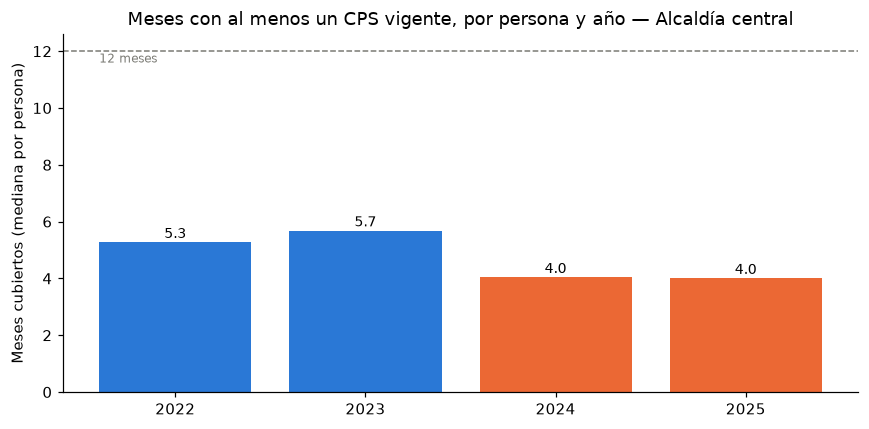

**Q02 · ¿Cuántos meses al año tiene contrato una persona?**  
Mediana por persona en la Alcaldía central: 2022: 5,3 meses (34 % con 7 o más; 3.526 personas); 2023: 5,7 meses (39 % con 7 o más; 3.035 personas); 2024: 4,0 meses (30 % con 7 o más; 2.661 personas); 2025: 4,0 meses (28 % con 7 o más; 3.233 personas).  
*Estado:* `PUBLICABLE` — *Límite:* Es una serie, no un ranking: 2022–23 son años 3–4 de un mandato y 2024–25 los años 1–2 del siguiente. No mide empleo ni ingresos de otras fuentes.

In [17]:
pa = L["persona_anio"]
cen = pa.loc[pa["ambito"].eq("Alcaldía central")]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cen["anio"].astype(str), cen["mediana_meses"], color=[su.COLORES[a] for a in cen["administracion"]])
ax.axhline(12, color=su.COLORES["neutro"], ls="--", lw=1)
ax.text(-0.4, 11.6, "12 meses", fontsize=8, color=su.COLORES["neutro"])
ax.set_ylabel("Meses cubiertos (mediana por persona)")
ax.set_title("Meses con al menos un CPS vigente, por persona y año — Alcaldía central")
for x, y in zip(range(len(cen)), cen["mediana_meses"]):
    ax.text(x, y + 0.15, f"{y:.1f}", ha="center", fontsize=9)
g2 = guardar_fig(fig, "g02_meses_cubiertos_persona_anio.png")
txt = "; ".join(f"{int(r.anio)}: {r.mediana_meses:.1f} meses ({r.pct_7_meses_o_mas:.0f} % con 7 o más; {int(r.personas):,} personas)"
                for r in cen.itertuples())
hallazgo("Q02", "¿Cuántos meses al año tiene contrato una persona?",
         f"Mediana por persona en la Alcaldía central: {txt}.",
         "CPS estrictos firmados por el gobierno en ejercicio; días únicos (sin duplicar simultáneos)", "2022–2025",
         su.rel(r05["persona_anio"], RAIZ), "Dato descriptivo", "PUBLICABLE",
         "Es una serie, no un ranking: 2022–23 son años 3–4 de un mandato y 2024–25 los años 1–2 del siguiente. "
         "No mide empleo ni ingresos de otras fuentes.", g2)

## Q03 · ¿Qué tan frecuente es volver a ser contratado?

In [18]:
bd, rc = L["bandas_recurrencia"], L["recurrencia"].set_index("indicador")["valor"]
cinco = bd.loc[bd["banda"].eq("5 o más")].iloc[0]
hallazgo("Q03", "¿Qué tan frecuente es volver a ser contratado?",
         f"De {int(rc.iloc[0]):,} personas observadas desde abril de 2021, el {bd.loc[bd['banda'].eq('1'), 'pct_personas'].item():.1f} % "
         f"tuvo un solo contrato y el {cinco['pct_personas']:.1f} % ({int(cinco['personas']):,}) cinco o más. "
         f"{int(rc.iloc[1]):,} personas tuvieron contratos firmados por ambos gobiernos.",
         "CPS estrictos, Alcaldía central, identidad apta", "abr-2021 a sep-2026", su.rel(r05["bandas_recurrencia"], RAIZ),
         "Patrón estadístico", "PUBLICABLE",
         "Recurrencia no es favoritismo ni renovación automática. El inventario tiene exposición distinta por gobierno.")

**Q03 · ¿Qué tan frecuente es volver a ser contratado?**  
De 8.663 personas observadas desde abril de 2021, el 40,1 % tuvo un solo contrato y el 22,5 % (1.948) cinco o más. 1.579 personas tuvieron contratos firmados por ambos gobiernos.  
*Estado:* `PUBLICABLE` — *Límite:* Recurrencia no es favoritismo ni renovación automática. El inventario tiene exposición distinta por gobierno.

## Q04 · Entre un contrato y el siguiente, ¿cuánto se espera?

In [19]:
ct = L["continuidad"]
cp = ct.loc[ct["ventana"].eq("anio3_ene_ago")].set_index("administracion")
hallazgo("Q04", "¿Cuánto se espera hasta el siguiente contrato, según el gobierno?",
         "No se publica una comparación entre gobiernos: con seguimiento igual, la probabilidad de volver a tener contrato cambia más "
         "entre años de terminación (año electoral o no) que entre gobiernos. La espera típica, sin distinguir gobierno, está en el P06 del 07.",
         "Episodios de CPS unidos por persona (Alcaldía central)", PERIODO_PRINCIPAL, su.rel(r05["continuidad"], RAIZ),
         "No sostenible con SECOP II por sí solo", "NO_PUBLICABLE",
         "Ventana de 8 meses con Ley de Garantías y censura; el resultado depende del año y no del gobierno.")

**Q04 · ¿Cuánto se espera hasta el siguiente contrato, según el gobierno?**  
No se publica una comparación entre gobiernos: con seguimiento igual, la probabilidad de volver a tener contrato cambia más entre años de terminación (año electoral o no) que entre gobiernos. La espera típica, sin distinguir gobierno, está en el P06 del 07.  
*Estado:* `NO_PUBLICABLE` — *Límite:* Ventana de 8 meses con Ley de Garantías y censura; el resultado depende del año y no del gobierno.

## Q05 · ¿Cambió el volumen de personas y contratos entre gobiernos? (ventana principal + robustez)

In [20]:
filas = []
for met, nombre in [("personas", "Personas"), ("contratos", "Contratos"), ("duracion_mediana_dias", "Duración mediana"),
                    ("cobertura_mediana_meses", "Meses cubiertos por persona"),
                    ("pct_personas_mitad_ventana_o_mas", "% personas con ≥ mitad de la ventana")]:
    mn, mx, pr = rango_cambio(met)
    filas.append({"indicador": nombre, "alfonso_principal": res("anio3_ene_ago", su.ADMINS[0], met),
                  "jonathan_principal": res("anio3_ene_ago", su.ADMINS[1], met), "cambio_principal": pr,
                  "rango_cambio_todas_ventanas": f"{mn:+.1f} a {mx:+.1f}", "dictamen": dictamen(met),
                  "estado_publicacion": estado_por_dictamen(dictamen(met))})
comparacion_completa = pd.DataFrame(filas)
# Tabla pública: sin filas NO_PUBLICABLE y sin cifra puntual en las SOLO_DIRECCION
comparacion = comparacion_completa.loc[comparacion_completa["estado_publicacion"].ne("NO_PUBLICABLE")].copy()
comparacion.loc[comparacion["estado_publicacion"].eq("SOLO_DIRECCION"), "cambio_principal"] = np.nan
mn, mx, pr = rango_cambio("personas")
hallazgo("Q05", "¿Hubo más personas contratadas con Jonathan?",
         f"En enero–agosto del tercer año hubo {res('anio3_ene_ago', su.ADMINS[1], 'personas'):,.0f} personas con CPS frente a "
         f"{res('anio3_ene_ago', su.ADMINS[0], 'personas'):,.0f}. La dirección (más personas) se mantiene en todas las ventanas, "
         f"pero la magnitud del aumento va de {mn:+.1f} % a {mx:+.1f} % según el periodo elegido; por eso se publica el rango.",
         "CPS estrictos, Alcaldía central, identidad apta", PERIODO_PRINCIPAL, su.rel(r04["robustez"], RAIZ),
         "Patrón estadístico", estado_por_dictamen(dictamen("personas")),
         "Descriptivo, no causal. Las ventanas de 17 meses usan 2021, cuya cobertura en SECOP II no está validada.")
comparacion.round(1)

**Q05 · ¿Hubo más personas contratadas con Jonathan?**  
En enero–agosto del tercer año hubo 3.123 personas con CPS frente a 2.819. La dirección (más personas) se mantiene en todas las ventanas, pero la magnitud del aumento va de +10,8 % a +26,5 % según el periodo elegido; por eso se publica el rango.  
*Estado:* `SOLO_DIRECCION` — *Límite:* Descriptivo, no causal. Las ventanas de 17 meses usan 2021, cuya cobertura en SECOP II no está validada.

,indicador,alfonso_principal,jonathan_principal,cambio_principal,rango_cambio_todas_ventanas,dictamen,estado_publicacion
0,Personas,2819.0,3123.0,NaN,+10.8 a +26.5,DIRECCION_ROBUSTA_MAGNITUD_SENSIBLE,SOLO_DIRECCION
1,Contratos,3378.0,4133.0,22.4,+22.4 a +25.4,ROBUSTO,PUBLICABLE_CON_CAUTELA
2,Duración mediana,126.0,120.0,NaN,-15.8 a -4.8,DIRECCION_ROBUSTA_MAGNITUD_SENSIBLE,SOLO_DIRECCION
3,Meses cubiertos por persona,4.1,3.9,NaN,-23.7 a -3.2,DIRECCION_ROBUSTA_MAGNITUD_SENSIBLE,SOLO_DIRECCION


## Q06 · Honorarios en pesos constantes: ¿cuándo cambiaron?

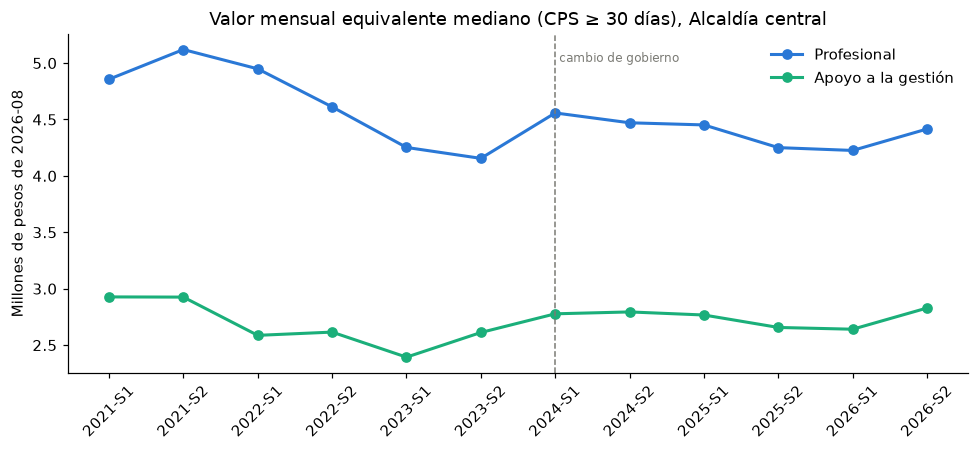

**Q06 · ¿Cuándo cambiaron los honorarios profesionales en términos reales?**  
La mediana real profesional cambió -14,4 % entre el primer semestre observado y el segundo de 2023 (gobierno de Alfonso), +9,7 % en el paso de gobierno (2023-S2 a 2024-S1) y -3,1 % desde entonces. La caída acumulada desde 2021 no puede atribuirse a un solo gobierno.  
*Estado:* `PUBLICABLE_CON_CAUTELA` — *Límite:* No es salario. Subtipo por texto (SIN_VALIDACION_MANUAL). Deflactado con IPC nacional por mes de firma.

**Q06B · ¿Pagó menos Jonathan a los profesionales que Alfonso?**  
No se publica una cifra: la serie semestral (Q06) muestra que la erosión real empezó en 2022 y 2023, antes del cambio de gobierno.  
*Estado:* `NO_PUBLICABLE` — *Límite:* Contrastar ventanas separadas cuatro años confunde tendencia inflacionaria con decisión de gobierno.

In [21]:
sh = L["serie_honorarios"]
tr = L["tramos_honorarios"]
fig, ax = plt.subplots(figsize=(9, 4.2))
for sub, color in [("Profesional", "#2a78d6"), ("Apoyo a la gestión", "#1baf7a")]:
    d = sh.loc[sh["subtipo_cps"].eq(sub)]
    ax.plot(d["semestre"], d["mediana_real"] / 1e6, marker="o", lw=2, ms=6, color=color, label=sub)
ax.axvline("2024-S1", color=su.COLORES["neutro"], ls="--", lw=1)
ax.text("2024-S1", ax.get_ylim()[1] * 0.97, " cambio de gobierno", fontsize=8, color=su.COLORES["neutro"], va="top")
ax.set_ylabel(f"Millones de pesos de {man04['conteos']['mes_base_ipc']}")
ax.set_title("Valor mensual equivalente mediano (CPS ≥ 30 días), Alcaldía central")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=45)
g6 = guardar_fig(fig, "g06_honorarios_semestrales_reales.png")
tp = tr.loc[tr["subtipo"].eq("Profesional")].set_index("tramo")["cambio_pct"]
hallazgo("Q06", "¿Cuándo cambiaron los honorarios profesionales en términos reales?",
         f"La mediana real profesional cambió {tp.iloc[0]:+.1f} % entre el primer semestre observado y el segundo de 2023 (gobierno de Alfonso), "
         f"{tp.iloc[1]:+.1f} % en el paso de gobierno (2023-S2 a 2024-S1) y {tp.iloc[2]:+.1f} % desde entonces. "
         "La caída acumulada desde 2021 no puede atribuirse a un solo gobierno.",
         "CPS de subtipo claro, identidad apta, ≥30 días, Alcaldía central", "2021-S1 a 2026-S2",
         su.rel(r04["serie_honorarios"], RAIZ), "Patrón estadístico", "PUBLICABLE_CON_CAUTELA",
         f"No es salario. Subtipo por texto ({VALIDACION}). Deflactado con IPC nacional por mes de firma.", g6)
hallazgo("Q06B", "¿Pagó menos Jonathan a los profesionales que Alfonso?",
         "No se publica una cifra: la serie semestral (Q06) muestra que la erosión real empezó en 2022 y 2023, antes del cambio de gobierno.",
         "Idem Q06", PERIODO_PRINCIPAL, su.rel(r04["robustez"], RAIZ), "No sostenible con SECOP II por sí solo",
         "NO_PUBLICABLE", "Contrastar ventanas separadas cuatro años confunde tendencia inflacionaria con decisión de gobierno.")

## Q07 · Valores mensuales más altos (sin nombres)

In [22]:
ipc = L["ipc"]
v = b.loc[b["es_central"] & b["apto_valor_mensual"] & b["duracion_dias_incl"].ge(90)].copy()
v["mes"] = v["fecha_firma"].dt.to_period("M").dt.to_timestamp()
v = v.merge(ipc, on="mes", how="inner")
v["real"] = v["valor_mensual_equiv"] * ipc["ipc_indice"].iloc[-1] / v["ipc_indice"]
p = v.groupby("subtipo_cps")["real"].describe(percentiles=[.5, .95, .99])[["count", "50%", "95%", "99%", "max"]]
extremos = v.loc[v["real"] > v.groupby("subtipo_cps")["real"].transform(lambda x: x.quantile(.99)),
                 ["id_contrato", "subtipo_cps", "fecha_firma", "duracion_dias_incl", "valor_contrato", "real", "url_secop"]]
INTERNO = SALIDA / "uso_interno_verificacion"  # listas re-identificables: no publicar
INTERNO.mkdir(exist_ok=True)
su.guardar_csv(extremos, INTERNO / "q07_extremos_para_verificar.csv")
(SALIDA / "q07_extremos_para_verificar.csv").unlink(missing_ok=True)  # copia pública de versiones anteriores
hallazgo("Q07", "¿Cuáles son los valores mensuales más altos?",
         f"Con contratos de 90 días o más, el 1 % superior de los profesionales supera {p.loc['Profesional', '99%'] / 1e6:.1f} millones "
         f"reales al mes (mediana {p.loc['Profesional', '50%'] / 1e6:.1f}). {len(extremos)} contratos quedan en la lista de verificación.",
         "CPS subtipo claro, ≥90 días, Alcaldía central", "abr-2021 a ago-2026", "datos/salidas/06_hallazgos/uso_interno_verificacion/q07_extremos_para_verificar.csv",
         "Anomalía para investigar", "SOLO_INVESTIGACION",
         "Un extremo puede ser error de registro, objeto distinto o forma de pago; revisar expediente antes de nombrar.")
p.round(0)

**Q07 · ¿Cuáles son los valores mensuales más altos?**  
Con contratos de 90 días o más, el 1 % superior de los profesionales supera 7,9 millones reales al mes (mediana 4,6). 182 contratos quedan en la lista de verificación.  
*Estado:* `SOLO_INVESTIGACION` — *Límite:* Un extremo puede ser error de registro, objeto distinto o forma de pago; revisar expediente antes de nombrar.

,count,50%,95%,99%,max
subtipo_cps,,,,,
Apoyo a la gestión,8984.0,2656636.0,3595001.0,4089009.0,7137629.0
Profesional,9251.0,4631801.0,6581716.0,7914794.0,21966736.0


## Q08 · Contratos simultáneos en varias entidades

In [23]:
sr = L["solapes_resumen"]
spr = sr.loc[sr["ventana"].eq("anio3_ene_ago") & sr["excluye_terminados"].astype(str).eq("True")]
conc = spr.loc[spr["relacion"].str.contains("Concejo") & spr["relacion"].str.contains("Alcaldía")]
tot = sr.loc[sr["ventana"].eq("anio3_ene_ago")].groupby("excluye_terminados")["personas"].sum()
hallazgo("Q08", "¿Hay personas con CPS simultáneos en varias entidades?",
         f"En la ventana principal hay {int(tot.get(False, 0) + tot.get(True, 0))} casos persona-relación con al menos 30 días de contratos "
         f"simultáneos en dos entidades; {int(tot.get(True, 0))} no involucran contratos en estado 'terminado'. No se comparan gobiernos: el "
         "estado 'terminado' depende de la antigüedad del contrato y la cobertura de otras entidades en SECOP II cambió.",
         "CPS estrictos, identidad apta, todas las entidades; ≥30 días de solape", PERIODO_PRINCIPAL,
         su.rel(r05["solapes_resumen"], RAIZ), "Anomalía para investigar", "SOLO_INVESTIGACION",
         "No prueba incompatibilidad: la simultaneidad formal no dice nada de horarios ni de dedicación; requiere expedientes.")

**Q08 · ¿Hay personas con CPS simultáneos en varias entidades?**  
En la ventana principal hay 205 casos persona-relación con al menos 30 días de contratos simultáneos en dos entidades; 142 no involucran contratos en estado 'terminado'. No se comparan gobiernos: el estado 'terminado' depende de la antigüedad del contrato y la cobertura de otras entidades en SECOP II cambió.  
*Estado:* `SOLO_INVESTIGACION` — *Límite:* No prueba incompatibilidad: la simultaneidad formal no dice nada de horarios ni de dedicación; requiere expedientes.

## Q09 · Firmas de contratación directa durante la Ley de Garantías

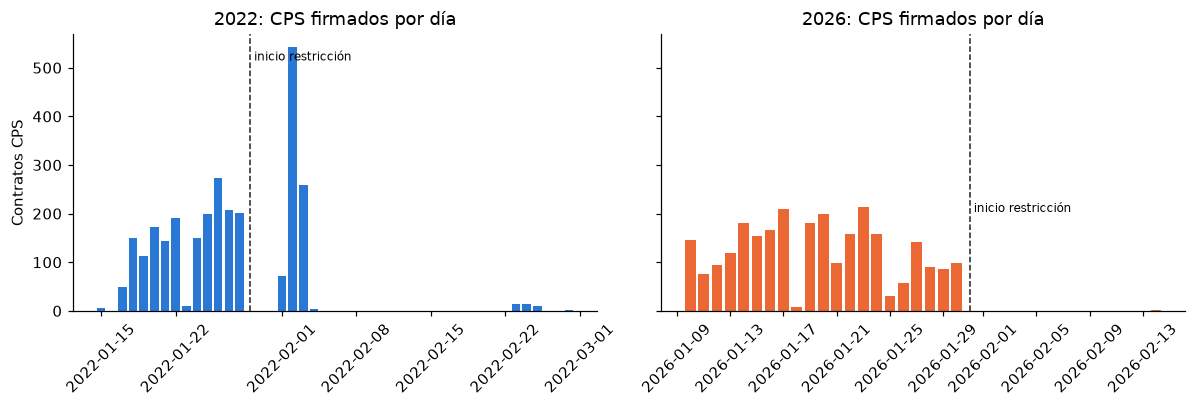

**Q09 · ¿Se firmaron contratos directos durante la Ley de Garantías?**  
SECOP II registra 947 contratos directos de la Alcaldía central con fecha de firma entre el 29-ene y el 19-jun-2022 (el mayor día: 2022-02-02 con 546), frente a 4 en el periodo equivalente de 2026.  
*Estado:* `PUBLICABLE_CON_CAUTELA` — *Límite:* Se publica el conteo, no una conclusión legal: el art. 33 tiene excepciones (defensa y seguridad, crédito público, emergencias educativas, sanitarias y desastres, entidades sanitarias y hospitalarias) y la fecha de firma de SECOP II puede no ser la de suscripción. Si hubo o no infracción solo lo dicen los expedientes.

In [24]:
lg = L["ley_garantias"]
dia = L["ley_garantias_por_dia"]
cen_lg = lg.loc[lg["grupo_atribucion"].eq("Administración central")].set_index("periodo")
alc = b.loc[b["es_central"] & b["es_cps_estricto"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (anio, ini, admin) in zip(axes, [(2022, "2022-01-29", su.ADMINS[0]), (2026, "2026-01-31", su.ADMINS[1])]):
    d = alc.loc[alc["fecha_firma"].between(f"{anio}-01-10", f"{anio}-02-28")].groupby("fecha_firma").size()
    ax.bar(d.index, d.values, color=su.COLORES[admin], width=0.8)
    ax.axvline(pd.Timestamp(ini), color="#222222", ls="--", lw=1)
    ax.text(pd.Timestamp(ini), d.max() * 0.95, " inicio restricción", fontsize=8)
    ax.set_title(f"{anio}: CPS firmados por día")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Contratos CPS")
g9 = guardar_fig(fig, "g09_firmas_ley_garantias.png")
n22 = int(cen_lg.loc["presidencial_2022", "contratos_directa"]) if "presidencial_2022" in cen_lg.index else 0
n26 = int(cen_lg.loc["presidencial_2026", "contratos_directa"]) if "presidencial_2026" in cen_lg.index else 0
hallazgo("Q09", "¿Se firmaron contratos directos durante la Ley de Garantías?",
         f"SECOP II registra {n22:,} contratos directos de la Alcaldía central con fecha de firma entre el 29-ene y el 19-jun-2022 "
         f"(el mayor día: {dia.sort_values('contratos').iloc[-1]['fecha_firma']:%Y-%m-%d} con {int(dia['contratos'].max())}), frente a {n26} en el periodo equivalente de 2026.",
         "Contratos válidos por contratación directa", "Periodos de restricción 2022 y 2026",
         su.rel(r05["ley_garantias"], RAIZ), "Dato descriptivo; su legalidad requiere expedientes", "PUBLICABLE_CON_CAUTELA",
         "Se publica el conteo, no una conclusión legal: el art. 33 tiene excepciones (defensa y seguridad, crédito público, emergencias "
         "educativas, sanitarias y desastres, entidades sanitarias y hospitalarias) y la fecha de firma de SECOP II puede no ser la de "
         "suscripción. Si hubo o no infracción solo lo dicen los expedientes.", g9)

## Q10 · Proveedores empresariales de la Alcaldía central

In [25]:
er = L["empresas_resumen"]
rr = L["empresas_recurrentes"].iloc[0]
hallazgo("Q10", "¿Qué empresas y consorcios contratan con la Alcaldía en ambos gobiernos?",
         f"{int(rr['en_ambos_gobiernos'])} de {int(rr['proveedores_central'])} proveedores persona jurídica o consorcio de la Alcaldía central "
         f"tienen contratos firmados en ambos gobiernos, por {rr['valor_real_de_recurrentes'] / 1e9:,.1f} mil millones de pesos constantes.",
         "Persona jurídica y grupo/consorcio, identidad apta (clasificación corregida)", "abr-2021 a ago-2026",
         su.rel(r05["empresas_recurrentes"], RAIZ), "Dato descriptivo", "PUBLICABLE_CON_CAUTELA",
         "Recurrencia no es favoritismo. Incluye entidades públicas y sin ánimo de lucro. Periodos de distinta duración.")
er

**Q10 · ¿Qué empresas y consorcios contratan con la Alcaldía en ambos gobiernos?**  
116 de 446 proveedores persona jurídica o consorcio de la Alcaldía central tienen contratos firmados en ambos gobiernos, por 766,9 mil millones de pesos constantes.  
*Estado:* `PUBLICABLE_CON_CAUTELA` — *Límite:* Recurrencia no es favoritismo. Incluye entidades públicas y sin ánimo de lucro. Periodos de distinta duración.

,administracion_firma,naturaleza_proveedor,contratos,proveedores,valor_real,sin_ipc
0,Alfonso Eljach,Grupo/consorcio,74,70,3.405660e+11,0
1,Alfonso Eljach,Persona jurídica,701,242,5.082637e+11,0
2,Jonathan Vásquez,Grupo/consorcio,58,53,1.782909e+11,0
3,Jonathan Vásquez,Persona jurídica,624,197,5.578083e+11,0


## Q11 · ESE Barrancabermeja

In [26]:
ese_r = L["ese_resumen"].iloc[0]
hallazgo("Q11", "¿Qué pasa con los contratos de personas en la ESE?",
         f"La ESE registra sus servicios bajo 'Decreto 092': {int(ese_r['registros_ese_por_revisar']):,} registros de "
         f"{int(ese_r['personas_ese_por_revisar']):,} personas parecen servicios personales, y {int(ese_r['personas_con_solape_central_30d'])} personas "
         "tuvieron simultáneamente un CPS con la Alcaldía.",
         "ESE, persona natural, objeto de servicios", "jul-2022 a sep-2026", su.rel(r05["ese_resumen"], RAIZ),
         "Afirmación que requiere revisión documental", "SOLO_INVESTIGACION",
         "No se confirman como CPS ni se suman a la Alcaldía; la ESE aparece en SECOP II desde jul-2022.")

**Q11 · ¿Qué pasa con los contratos de personas en la ESE?**  
La ESE registra sus servicios bajo 'Decreto 092': 1.830 registros de 1.017 personas parecen servicios personales, y 73 personas tuvieron simultáneamente un CPS con la Alcaldía.  
*Estado:* `SOLO_INVESTIGACION` — *Límite:* No se confirman como CPS ni se suman a la Alcaldía; la ESE aparece en SECOP II desde jul-2022.

## Q12 · ¿Qué profesiones son más estables?

In [27]:
hallazgo("Q12", "¿Qué profesiones ofrecen más estabilidad?",
         "No es posible responderlo con SECOP II: el objeto contractual no acredita la profesión y no hay validación manual.",
         "—", "—", "—", "No sostenible con SECOP II por sí solo", "NO_PUBLICABLE", "Requiere otra fuente (hojas de vida, SIGEP).")

**Q12 · ¿Qué profesiones ofrecen más estabilidad?**  
No es posible responderlo con SECOP II: el objeto contractual no acredita la profesión y no hay validación manual.  
*Estado:* `NO_PUBLICABLE` — *Límite:* Requiere otra fuente (hojas de vida, SIGEP).

## Catálogo, afirmaciones no sostenibles y controles

In [28]:
catalogo = pd.DataFrame(hallazgos)
no_sostenibles = pd.DataFrame([
    ("Los CPS son empleos o el valor mensual es un salario", "SECOP registra contratos y valores pactados, no pagos ni relación laboral."),
    ("Un gobierno pagó menos a los profesionales", "La caída real empieza antes del cambio de gobierno (Q06)."),
    ("Un gobierno generó más continuidad o más empleo", "Las cifras cambian según la ventana y la etapa del mandato."),
    ("Dos contratos simultáneos prueban ilegalidad", "Hay que revisar dedicación, obligaciones y pagos."),
    ("Las firmas en Ley de Garantías fueron ilegales", "Puede haber excepciones y diferencias entre firma electrónica y suscripción."),
    ("Recurrencia de personas o empresas prueba favoritismo", "Es un patrón descriptivo con explicaciones alternativas."),
    ("El Concejo o los órganos de control son contratación del alcalde", "Son entidades autónomas; se analizan separadas."),
], columns=["afirmacion", "razon"])

ctl = su.Controles()
ctl.agregar("Estados de publicación cerrados", set(catalogo["estado_publicacion"]) <= {
    "PUBLICABLE", "PUBLICABLE_CON_CAUTELA", "SOLO_DIRECCION", "SOLO_INVESTIGACION", "NO_PUBLICABLE"}, True)
ctl.agregar("Comparaciones NO_ROBUSTAS marcadas no publicables",
            bool(comparacion_completa.loc[comparacion_completa["dictamen"].eq("NO_ROBUSTO"), "estado_publicacion"].eq("NO_PUBLICABLE").all()), True)
ctl.agregar("Tablas públicas sin columna de nombres",
            not any("nombre" in col for col in catalogo.columns.tolist() + extremos.columns.tolist()), True)
ctl.agregar("Todas las evidencias existen", all((RAIZ / e).exists() for e in catalogo["evidencia"] if e not in ("—",)), True)
ctl.agregar("Todas las gráficas existen", all((RAIZ / g).exists() for g in catalogo["grafico"] if g), True)
tabla_ctl = ctl.tabla()
display(catalogo[["id", "pregunta", "clasificacion", "estado_publicacion"]]); display(tabla_ctl)

salidas = {
    "catalogo_hallazgos": su.guardar_csv(catalogo, SALIDA / "catalogo_hallazgos.csv"),
    "comparacion_principal": su.guardar_csv(comparacion, SALIDA / "q05_comparacion_principal_robustez.csv"),
    "distribucion_duracion": su.guardar_csv(dist.reset_index(), SALIDA / "q01_distribucion_duracion.csv"),
    "percentiles_valor": su.guardar_csv(p.drop(columns="max").reset_index(), SALIDA / "q07_percentiles_valor_mensual.csv"),  # sin el máximo
    "extremos": INTERNO / "q07_extremos_para_verificar.csv",
    "afirmaciones_no_sostenibles": su.guardar_csv(no_sostenibles, SALIDA / "afirmaciones_no_sostenibles.csv"),
    "controles": su.guardar_csv(tabla_ctl, SALIDA / "controles_06.csv"),
    **{f"grafico_{Path(g).stem}": RAIZ / g for g in catalogo["grafico"] if g},
}
estado = "BLOQUEADO" if ctl.bloqueos() else "VALIDADO_REQUIERE_REVISION_EDITORIAL"
man = su.cerrar_etapa(RAIZ, ETAPA, VERSION_NB, {k: su.huella_entrada(m) for k, m in [("03", man03), ("04", man04), ("05", man05)]},
                      salidas, reglas={"publicacion": "Estado asignado por dictamen de robustez y clase de evidencia.",
                                       "privacidad": "Sin nombres en salidas públicas."},
                      conteos=catalogo["estado_publicacion"].value_counts().to_dict(), estado=estado, alertas=ctl.bloqueos())
if ctl.bloqueos():
    raise RuntimeError(f"Etapa 06 bloqueada: {ctl.bloqueos()}")
print(man["estado"])

,id,pregunta,clasificacion,estado_publicacion
0,Q01,¿Cuánto dura un CPS?,Dato descriptivo,PUBLICABLE
1,Q02,¿Cuántos meses al año tiene contrato una persona?,Dato descriptivo,PUBLICABLE
2,Q03,¿Qué tan frecuente es volver a ser contratado?,Patrón estadístico,PUBLICABLE
3,Q04,"¿Cuánto se espera hasta el siguiente contrato,...",No sostenible con SECOP II por sí solo,NO_PUBLICABLE
4,Q05,¿Hubo más personas contratadas con Jonathan?,Patrón estadístico,SOLO_DIRECCION
5,Q06,¿Cuándo cambiaron los honorarios profesionales...,Patrón estadístico,PUBLICABLE_CON_CAUTELA
6,Q06B,¿Pagó menos Jonathan a los profesionales que A...,No sostenible con SECOP II por sí solo,NO_PUBLICABLE
7,Q07,¿Cuáles son los valores mensuales más altos?,Anomalía para investigar,SOLO_INVESTIGACION
8,Q08,¿Hay personas con CPS simultáneos en varias en...,Anomalía para investigar,SOLO_INVESTIGACION
9,Q09,¿Se firmaron contratos directos durante la Ley...,Dato descriptivo; su legalidad requiere expedi...,PUBLICABLE_CON_CAUTELA


,prueba,resultado,esperado,severidad,pasa
0,Estados de publicación cerrados,True,True,Crítica,True
1,Comparaciones NO_ROBUSTAS marcadas no publicables,True,True,Crítica,True
2,Tablas públicas sin columna de nombres,True,True,Crítica,True
3,Todas las evidencias existen,True,True,Crítica,True
4,Todas las gráficas existen,True,True,Crítica,True


VALIDADO_REQUIERE_REVISION_EDITORIAL
